In [1]:
import pandas as pd
import numpy as np
import cobra

In [2]:
# loading both datasets 
#geo_df  = pd.read_csv("GSE50760_norm_counts_TPM_GRCh38.p13_NCBI.tsv", sep="\t", index_col=0
tcga_data_path = "/Users/valentinreateguirangel/dissertation_project/data/TCGA_LIver/TCGA-LIHC.star_tpm.tsv.gz.tsv"
tcga_df = pd.read_csv(tcga_data_path, sep="\t", index_col=0, compression="gzip")

## Data exploration

In [4]:
#TCGA size
print(tcga_df.shape)

(60660, 424)


In [5]:
# Checkin for NA values 
print(tcga_df.isna().sum().sum())

0


In [6]:
# Checking for duplicates 
print(tcga_df.index.duplicated().sum())    

0


## Data standarization 

In [8]:
# Remove vesrion numbers .00
tcga_df.index = tcga_df.index.str.split('.').str[0]

In [9]:
# Checkinf for duplicates
print(tcga_df.index.duplicated().sum())   

44


In [10]:
# Get the duplicated index values
duplicated_indices = tcga_df.index[tcga_df.index.duplicated()]
print(duplicated_indices)

Index(['ENSG00000002586', 'ENSG00000124333', 'ENSG00000124334',
       'ENSG00000167393', 'ENSG00000169084', 'ENSG00000169093',
       'ENSG00000169100', 'ENSG00000178605', 'ENSG00000182162',
       'ENSG00000182378', 'ENSG00000182484', 'ENSG00000185203',
       'ENSG00000185291', 'ENSG00000185960', 'ENSG00000196433',
       'ENSG00000197976', 'ENSG00000198223', 'ENSG00000205755',
       'ENSG00000214717', 'ENSG00000223274', 'ENSG00000223484',
       'ENSG00000223511', 'ENSG00000223571', 'ENSG00000223773',
       'ENSG00000225661', 'ENSG00000226179', 'ENSG00000227159',
       'ENSG00000228410', 'ENSG00000228572', 'ENSG00000229232',
       'ENSG00000230542', 'ENSG00000234622', 'ENSG00000234958',
       'ENSG00000236017', 'ENSG00000236871', 'ENSG00000237040',
       'ENSG00000237531', 'ENSG00000237801', 'ENSG00000265658',
       'ENSG00000270726', 'ENSG00000275287', 'ENSG00000277120',
       'ENSG00000280767', 'ENSG00000281849'],
      dtype='object', name='Ensembl_ID')


In [11]:
# Get all rows with duplicated indices (including the first occurrence)
duplicates_df = tcga_df.loc[tcga_df.index.isin(duplicated_indices)]
display(duplicates_df)

,TCGA-5R-AA1C-01A,TCGA-ED-A66Y-01A,TCGA-DD-AAEI-01A,TCGA-ED-A8O5-01A,TCGA-DD-A3A2-11A,TCGA-DD-AACH-01A,TCGA-FV-A3R3-01A,TCGA-G3-A5SJ-01A,TCGA-HP-A5MZ-01A,TCGA-ZP-A9D0-01A,...,TCGA-DD-A3A5-01A,TCGA-DD-AACY-01A,TCGA-DD-AACC-01A,TCGA-CC-A7IH-01A,TCGA-BW-A5NO-01A,TCGA-CC-A7IJ-01A,TCGA-G3-AAV1-01A,TCGA-DD-AACI-01A,TCGA-CC-A9FS-01A,TCGA-GJ-A3OU-01A
Ensembl_ID,,,,,,,,,,,,,,,,,,,,,
ENSG00000002586,8.008248,5.908952,6.710480,6.519952,5.845987,7.256631,7.033326,5.620463,7.008367,6.775282,...,6.691665,6.030069,6.452923,7.243379,7.015459,8.543333,7.125336,6.208591,5.709555,6.726166
ENSG00000002586,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000124333,7.479809,5.861343,4.686209,5.416255,4.868341,6.126384,5.839803,5.282032,6.015894,5.845676,...,4.853741,6.396980,4.728448,7.624174,6.686583,5.687369,5.921974,5.614545,6.521434,5.593521
ENSG00000124333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000124334,0.079839,0.000000,0.060601,0.000000,0.024320,0.031113,0.029276,0.064607,0.026871,0.000000,...,0.000000,0.031254,0.037593,0.000000,0.060877,0.588900,0.000000,0.000000,0.000000,0.505383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000277120,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000280767,0.000000,0.494057,0.143263,0.631523,0.114500,0.145090,0.262313,0.152248,0.450485,0.000000,...,0.322390,0.400429,0.174023,0.479024,0.504773,0.331132,0.138159,0.508631,0.745625,0.196229
ENSG00000280767,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [12]:
# Getting only duplicated rows for processing 
duplicate_rows = tcga_df.loc[duplicated_indices]

In [13]:
# Keeping only non "0"
non_zero_duplicates = duplicate_rows.loc[~(duplicate_rows == 0).all(axis=1)]

In [14]:
# Droping duplicates with all "0"
tcga_df_cleaned = tcga_df.drop(index= duplicated_indices)
tcga_df_cleaned = pd.concat([tcga_df_cleaned, non_zero_duplicates])

In [15]:
# Sorting out index
tcga_df_cleaned = tcga_df_cleaned.sort_index()

In [16]:
# Checking for duplicates
print(tcga_df_cleaned.index.duplicated().sum())    

0


## Relabeling TCGA data

In [18]:
# Relabeling function
def label_tcga(col):
    try:
        parts = col.split('-')
        if len(parts) < 4:
            return f"TCGA_{col}"
        sample_code = parts[3][:2]
        condition = "Tumor" if sample_code == "01" else "Healthy" if sample_code == "11" else "Other"
        patient_id = parts[2]  
        return f"TCGA_{condition}_{patient_id}"
    except:
        return f"TCGA_Unknown_{col}"

In [19]:
tcga_labeled = tcga_df_cleaned.copy()
tcga_labeled.columns = [label_tcga(col) for col in tcga_labeled.columns]

In [20]:
print (tcga_labeled.head())
print(tcga_labeled.index.duplicated().sum())   

                 TCGA_Tumor_AA1C  TCGA_Tumor_A66Y  TCGA_Tumor_AAEI  \
Ensembl_ID                                                           
ENSG00000000003         6.863447         5.221413         5.315668   
ENSG00000000005         0.254836         0.000000         0.051581   
ENSG00000000419         6.909411         5.999260         5.328535   
ENSG00000000457         3.362007         3.694713         1.576909   
ENSG00000000460         4.462321         2.120053         0.805045   

                 TCGA_Tumor_A8O5  TCGA_Healthy_A3A2  TCGA_Tumor_AACH  \
Ensembl_ID                                                             
ENSG00000000003         5.766399           5.427251         3.865988   
ENSG00000000005         0.157044           0.264957         0.000000   
ENSG00000000419         5.013636           5.325527         6.363115   
ENSG00000000457         3.533090           1.848197         3.927157   
ENSG00000000460         2.011424           0.408821         3.301427   

    

## Model  TCGA
TCGA, it will be relabeled and then converted in to single vectors for iMat

In [22]:
tcga_only= tcga_labeled.copy()

In [23]:
# Relabeling using previous function def.label_tcga 
tcga_only.columns = [label_tcga(col) for col in tcga_only.columns]

Check for duble values also analysing the values dristribution fo the gene expressions 

In [25]:
# Spliting healhty to tumour, spliting by column label
tcga_tumor_df   = tcga_only.loc[:, tcga_only.columns.str.contains("Tumor")]
tcga_healthy_df = tcga_only.loc[:, tcga_only.columns.str.contains("Healthy")]

In [26]:
print (tcga_tumor_df.shape)
print (tcga_healthy_df.shape)

(60616, 371)
(60616, 50)


#### Data Visualization 

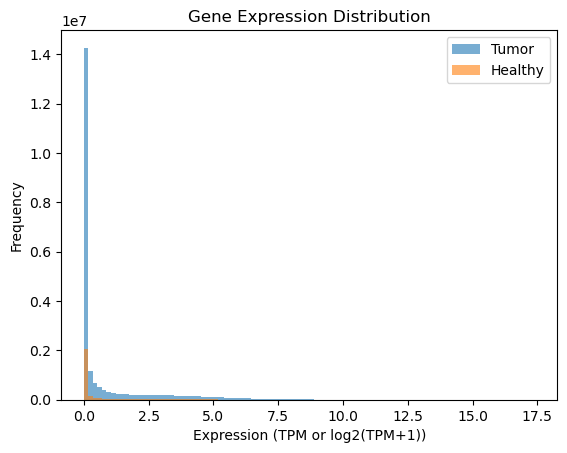

In [28]:
import matplotlib.pyplot as plt

# Flatten the values into one array per dataset
tumor_vals = tcga_tumor_df.values.flatten()
healthy_vals = tcga_healthy_df.values.flatten()

plt.hist(tumor_vals, bins=100, alpha=0.6, label='Tumor')
plt.hist(healthy_vals, bins=100, alpha=0.6, label='Healthy')
plt.xlabel("Expression (TPM or log2(TPM+1))")
plt.ylabel("Frequency")
plt.title("Gene Expression Distribution")
plt.legend()
plt.show()

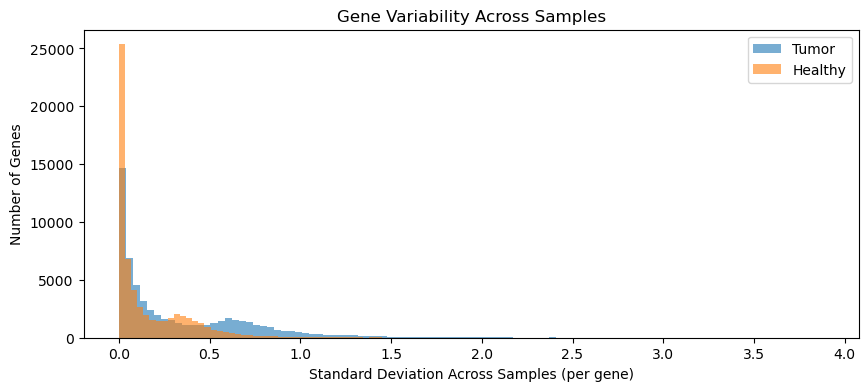

In [29]:
# Standard deviation across genes 
tumor_gene_std = tcga_tumor_df.std(axis=1)
healthy_gene_std = tcga_healthy_df.std(axis=1)

plt.figure(figsize=(10,4))
plt.hist(tumor_gene_std, bins=100, alpha=0.6, label='Tumor')
plt.hist(healthy_gene_std, bins=100, alpha=0.6, label='Healthy')
plt.xlabel("Standard Deviation Across Samples (per gene)")
plt.ylabel("Number of Genes")
plt.title("Gene Variability Across Samples")
plt.legend()
plt.show()

### PCA to see diversity among all tumor samples 

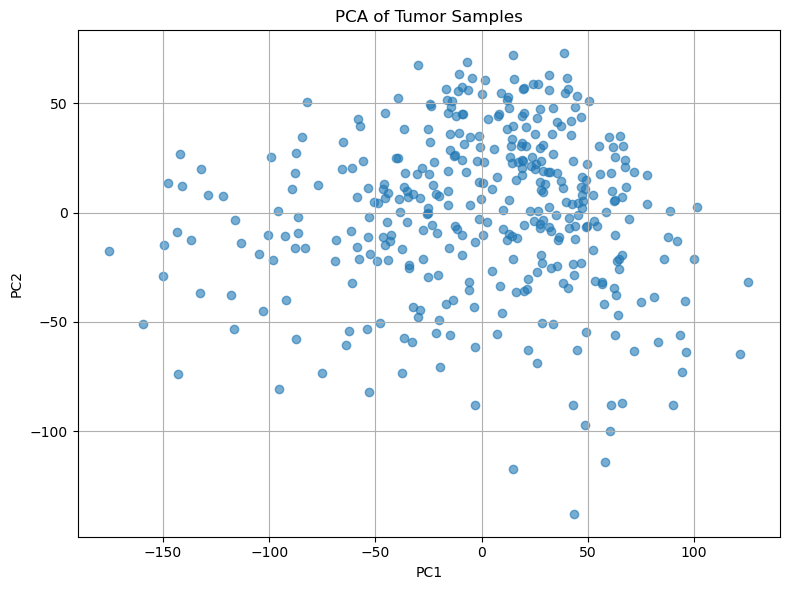

In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Transpose: now samples are rows
tumor_data = tcga_tumor_df.T

# Run PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(tumor_data)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6)
plt.title("PCA of Tumor Samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

### PCA to see diversity among all healthy samples 

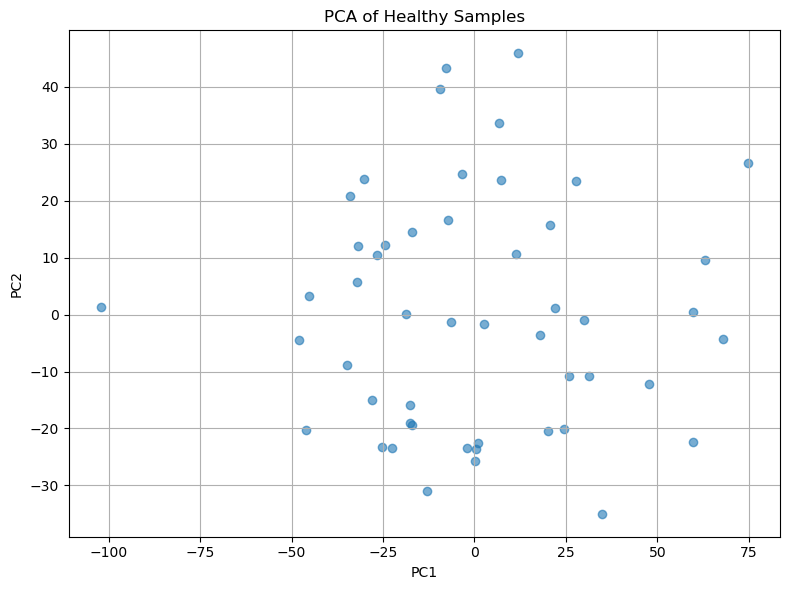

In [33]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Transpose: now samples are rows
healthy_data = tcga_healthy_df.T

# Run PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(healthy_data)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6)
plt.title("PCA of Healthy Samples")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

## Density and Ambiguity plots 

In [35]:
# Desnsity plot of al TPM values in the data (All genes x )
# Flattening data 
tpm_values = tcga_only.values.flatten()

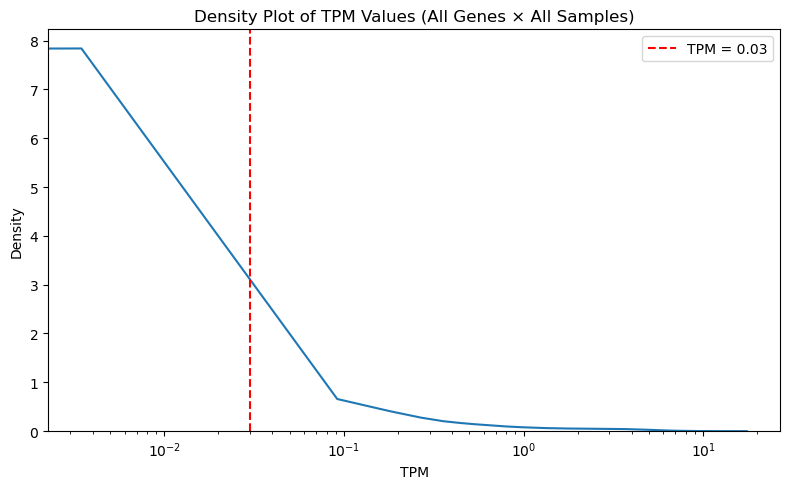

In [36]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(tpm_values, bw_adjust=0.5)
plt.axvline(0.03, color='red', linestyle='--', label='TPM = 0.03')
plt.title("Density Plot of TPM Values (All Genes × All Samples)")
plt.xlabel("TPM")
plt.ylabel("Density")
plt.xscale('log') 
plt.legend()
plt.tight_layout()
plt.show()

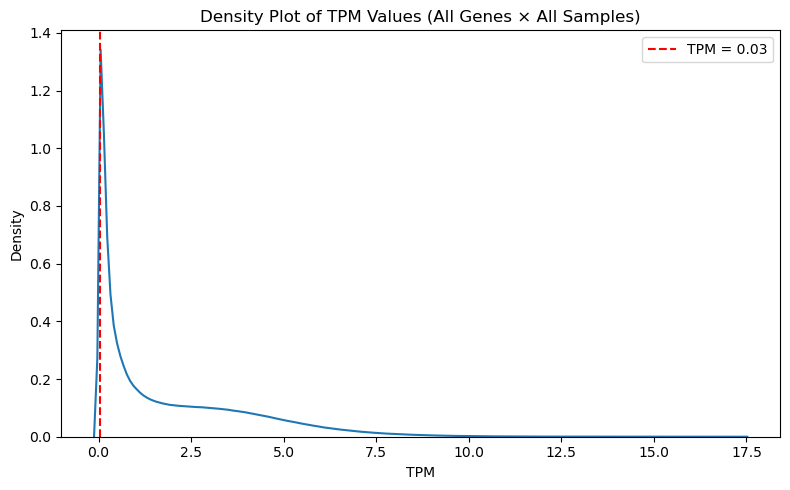

In [37]:
# Density plot, filtering values = 0 or negatives if they exist 
tpm_threshold_value = tpm_values[tpm_values > 0]

plt.figure(figsize=(8, 5))
sns.kdeplot(tpm_threshold_value, bw_adjust=0.5)
plt.axvline(0.03, color='red', linestyle='--', label='TPM = 0.03')
plt.title("Density Plot of TPM Values (All Genes × All Samples)")
plt.xlabel("TPM")
plt.ylabel("Density")
#plt.xscale('log')  
plt.legend()
plt.tight_layout()
plt.show()

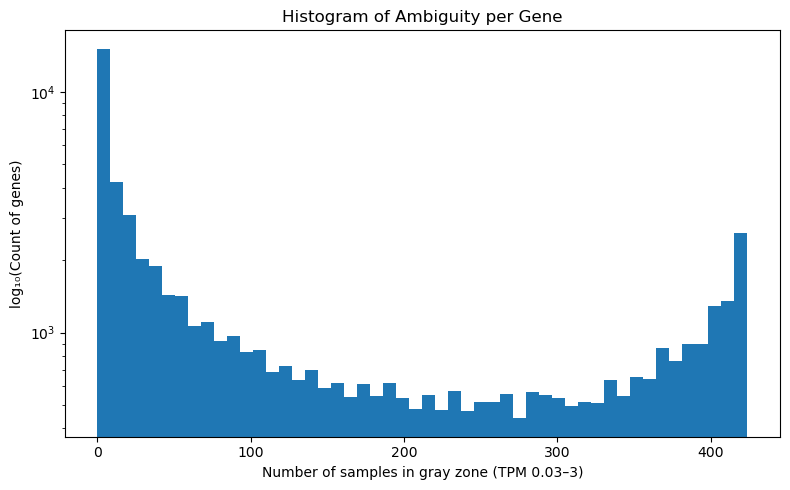

In [38]:
# Histogram of ambiguity per gene 
# Define gray zone thresholds
lower_thresh = 0.03
upper_thresh = 3

# Count ambiguity per gene, samples in the grey zone
ambiguity_counts = tcga_only.apply(lambda row: ((row >= lower_thresh) & (row <= upper_thresh)).sum(), axis=1)

# Histogram (log scale on y-axis)
plt.figure(figsize=(8, 5))
plt.hist(ambiguity_counts, bins=50)
plt.yscale('log')
plt.title("Histogram of Ambiguity per Gene")
plt.xlabel("Number of samples in gray zone (TPM 0.03–3)")
plt.ylabel("log₁₀(Count of genes)")
plt.tight_layout()
plt.show()

In [39]:
print (ambiguity_counts)

Ensembl_ID
ENSG00000000003      1
ENSG00000000005    260
ENSG00000000419      0
ENSG00000000457    350
ENSG00000000460    387
                  ... 
ENSG00000288669     82
ENSG00000288670    112
ENSG00000288671      0
ENSG00000288674    259
ENSG00000288675    416
Length: 60616, dtype: int64


## Full set & 90 ambiguity pure, (Tumor and healhty each)

#### Picking genes with at least 90% pure of ambiguity values 
Will clear noisy genes and retain a clean mayority。

In [42]:
# Number of samples
n_samples = tcga_only.shape[1]

# Defining ambiguity theshold (70% of total sample count)
max_ambigous = int(n_samples * 0.70)

In [43]:
# Ambiguity filter 
# Mask for genes with <= 70% ambiguity
keep_genes_mask = ambiguity_counts <= max_ambigous 

# Applying 
less_ambigous_tcga = tcga_only.loc[keep_genes_mask]

In [44]:
# Check how many genes remain
print(f"Original genes: {tcga_only.shape[0]}")
print(f"Filtered genes: {less_ambigous_tcga.shape[0]}")

Original genes: 60616
Filtered genes: 47431


### No filering , full ambigous

In [46]:
full_ambigous = tcga_only.copy()
print(f"Full ambigous genes: {full_ambigous.shape[0]}")

Full ambigous genes: 60616


# Discrete Model
Row-wise 25th/75th percentile to +-1/0, assigning per-sample ±1/0/–1 labels with the 25ᵗʰ/75ᵗʰ-percentile rule

In [48]:
# Discreatizing function 
def discretize_row(row): 
    q25 = row.quantile(0.25)
    q75 = row.quantile(0.75)
    return row.apply(lambda x : 1 if x >= q75 else ( -1 if x <= q25 else 0 ) )

### Discretising for less ambigous 

In [50]:
# applying function
tcga_discrete = less_ambigous_tcga.apply(discretize_row, axis=1)
print(f"Less ambigous genes: {tcga_discrete.shape[0]}")

Less ambigous genes: 47431


### Discreising for full ambigous

In [52]:
# applying function
tcga_discrete_ambigous = full_ambigous.apply(discretize_row, axis=1)
print(f"Full ambigous genes: {tcga_discrete_ambigous.shape[0]}")

Full ambigous genes: 60616


### Spliting main data to tumor and healthy

In [54]:
# Less ambigous
tcga_tumor   = tcga_discrete.loc[:, tcga_only.columns.str.contains("Tumor")]
tcga_healthy = tcga_discrete.loc[:, tcga_only.columns.str.contains("Healthy")]

# Full ambigous
tcga_tumor_amb   = tcga_discrete_ambigous.loc[:, tcga_only.columns.str.contains("Tumor")]
tcga_healthy_amb = tcga_discrete_ambigous.loc[:, tcga_only.columns.str.contains("Healthy")]

### Collapsing Datasets for iMat

Collapsing to one vector each tcga dataframe , same approach used by FASTCORMICS :
- If ≥90% of samples have +1 ----> final value = +1
- If ≥90% of samples have -1 ----> final value = -1
- Else ----> final value = 0

In [56]:
# Fascormics function like
def collapse_by_voting(df):
    def vote(row):
        total = len(row)
        count_pos = (row == 1).sum()
        count_neg = (row == -1).sum()
        if count_pos / total >= 0.7:
            return 1
        elif count_neg / total >= 0.7:
            return -1
        else:
            return 0
    return df.apply(vote, axis=1)

In [57]:
# Applying fucntion less ambigous 
tumor_vector = collapse_by_voting(tcga_tumor)
healthy_vector = collapse_by_voting(tcga_healthy)

In [58]:
# Applying fucntion full ambigous 
tumor_vector_amb = collapse_by_voting(tcga_tumor_amb)
healthy_vector_amb = collapse_by_voting(tcga_healthy_amb)

### Visual exploration of the data 

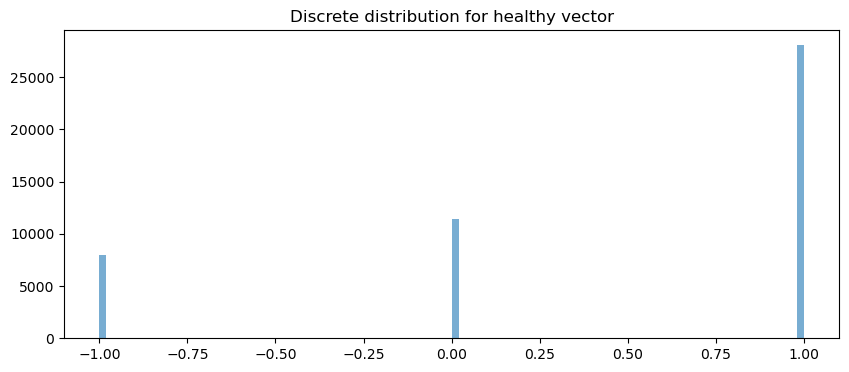

In [60]:
# Data visualization for Healhty less ambigous
plt.figure(figsize=(10,4))
plt.hist(healthy_vector, bins=100, alpha=0.6, label='Tumor')
plt.title("Discrete distribution for healthy vector")
plt.show()

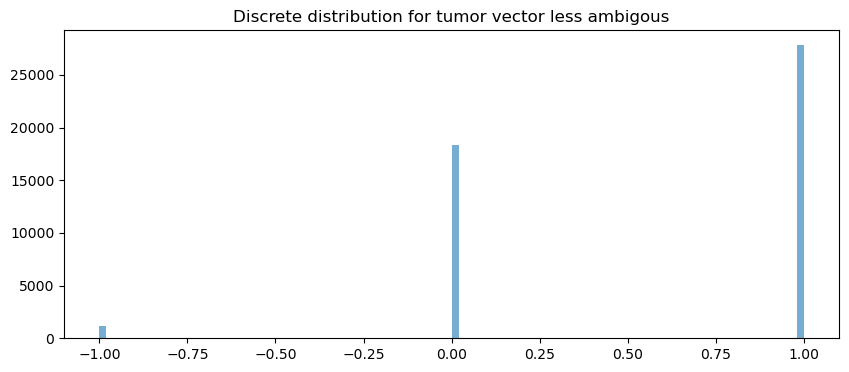

In [61]:
# Data visualization for tumor less ambigous

plt.figure(figsize=(10,4))
plt.hist(tumor_vector, bins=100, alpha=0.6, label='Tumor')
plt.title("Discrete distribution for tumor vector less ambigous")
plt.show()

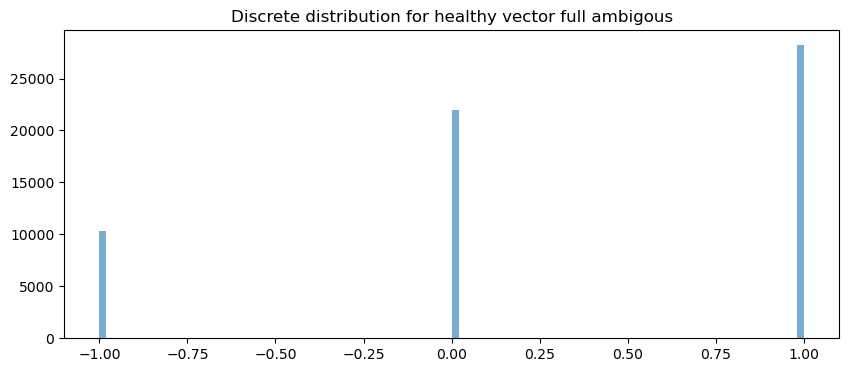

In [62]:
# Data visualization for Healhty full ambigous

plt.figure(figsize=(10,4))
plt.hist(healthy_vector_amb, bins=100, alpha=0.6, label='Tumor')
plt.title("Discrete distribution for healthy vector full ambigous")
plt.show()

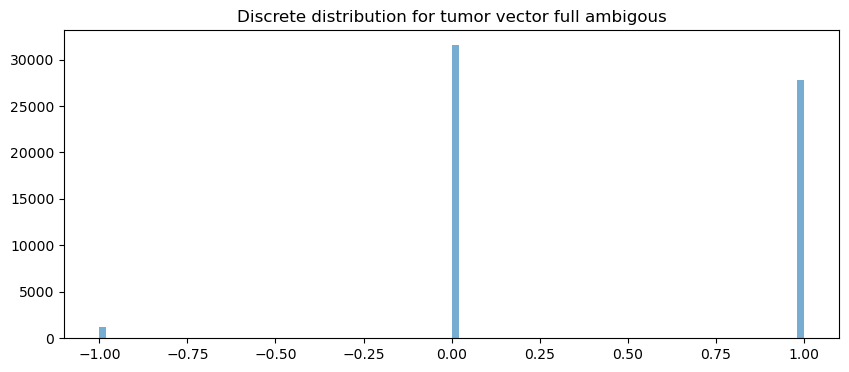

In [63]:
# Data visualization for tumor full ambigous
plt.figure(figsize=(10,4))
plt.hist(tumor_vector_amb, bins=100, alpha=0.6, label='Tumor')
plt.title("Discrete distribution for tumor vector full ambigous")
plt.show()

Data needs to be formated to be suitable for matlab

In [65]:
# Reformating 
#For tumor 
tumor_vector_df = tumor_vector.reset_index()
tumor_vector_df.columns = ['GeneID', 'Expression']

tumor_vector_amb_df = tumor_vector_amb.reset_index()
tumor_vector_amb_df.columns = ['GeneID', 'Expression']

#For healthy
healthy_vector_df = healthy_vector.reset_index()
healthy_vector_df.columns = ['GeneID', 'Expression']

healthy_vector_amb_df = healthy_vector_amb.reset_index()
healthy_vector_amb_df.columns = ['GeneID', 'Expression']


In [66]:
# Exporting values 
tumor_vector_df.to_csv("tumor_expression_vector70.txt", sep="\t", index=False, header=False)
healthy_vector_df.to_csv("healthy_expression_vector70.txt", sep="\t", index=False, header=False)

tumor_vector_amb_df.to_csv("tumor_expression_vector_full.txt", sep="\t", index=False, header=False)
healthy_vector_amb_df.to_csv("healthy_expression_vector_full.txt", sep="\t", index=False, header=False)


# Continuous Models 

In [68]:
print(f"Full ambigous genes: {full_ambigous.shape[0]}")
print(full_ambigous.isna().sum().sum())

Full ambigous genes: 60616
0


In [69]:
print(f"Less ambigous genes: {less_ambigous_tcga.shape[0]}")
print(less_ambigous_tcga.isna().sum().sum())
print(less_ambigous_tcga.head())

Less ambigous genes: 47431
0
                 TCGA_TCGA_Tumor_AA1C  TCGA_TCGA_Tumor_A66Y  \
Ensembl_ID                                                    
ENSG00000000003              6.863447              5.221413   
ENSG00000000005              0.254836              0.000000   
ENSG00000000419              6.909411              5.999260   
ENSG00000000971              9.331555              4.040410   
ENSG00000001036              4.587533              5.958673   

                 TCGA_TCGA_Tumor_AAEI  TCGA_TCGA_Tumor_A8O5  \
Ensembl_ID                                                    
ENSG00000000003              5.315668              5.766399   
ENSG00000000005              0.051581              0.157044   
ENSG00000000419              5.328535              5.013636   
ENSG00000000971              8.066063              8.087634   
ENSG00000001036              6.073636              5.112400   

                 TCGA_TCGA_Healthy_A3A2  TCGA_TCGA_Tumor_AACH  \
Ensembl_ID            

In [70]:
# Spliting datasets 
# Less ambigous
tcga_cont_Ambfiltered_tumor   = less_ambigous_tcga.loc[:, less_ambigous_tcga.columns.str.contains("Tumor")]
tcga_cont_Ambfiltered_healthy = less_ambigous_tcga.loc[:, less_ambigous_tcga.columns.str.contains("Healthy")]

# Full ambigous
tcga_cont_full_tumor   = full_ambigous.loc[:, full_ambigous.columns.str.contains("Tumor")]
tcga_cont_full_healthy = full_ambigous.loc[:, full_ambigous.columns.str.contains("Healthy")]

## Median method

In [72]:
# Calculating median across both datasets full ambigous and less 
# Less ambigous 
tcga_Ambfilt_cont_healthy_median = tcga_cont_Ambfiltered_healthy.median(axis=1)
tcga_Ambfilt_cont_tumor_median = tcga_cont_Ambfiltered_tumor.median(axis=1)

# Full ambigous 
tcga_full_cont_healthy_median = tcga_cont_full_healthy.median(axis=1)
tcga_full_cont_tumor_median = tcga_cont_full_tumor.median(axis=1)

## Data visualization 

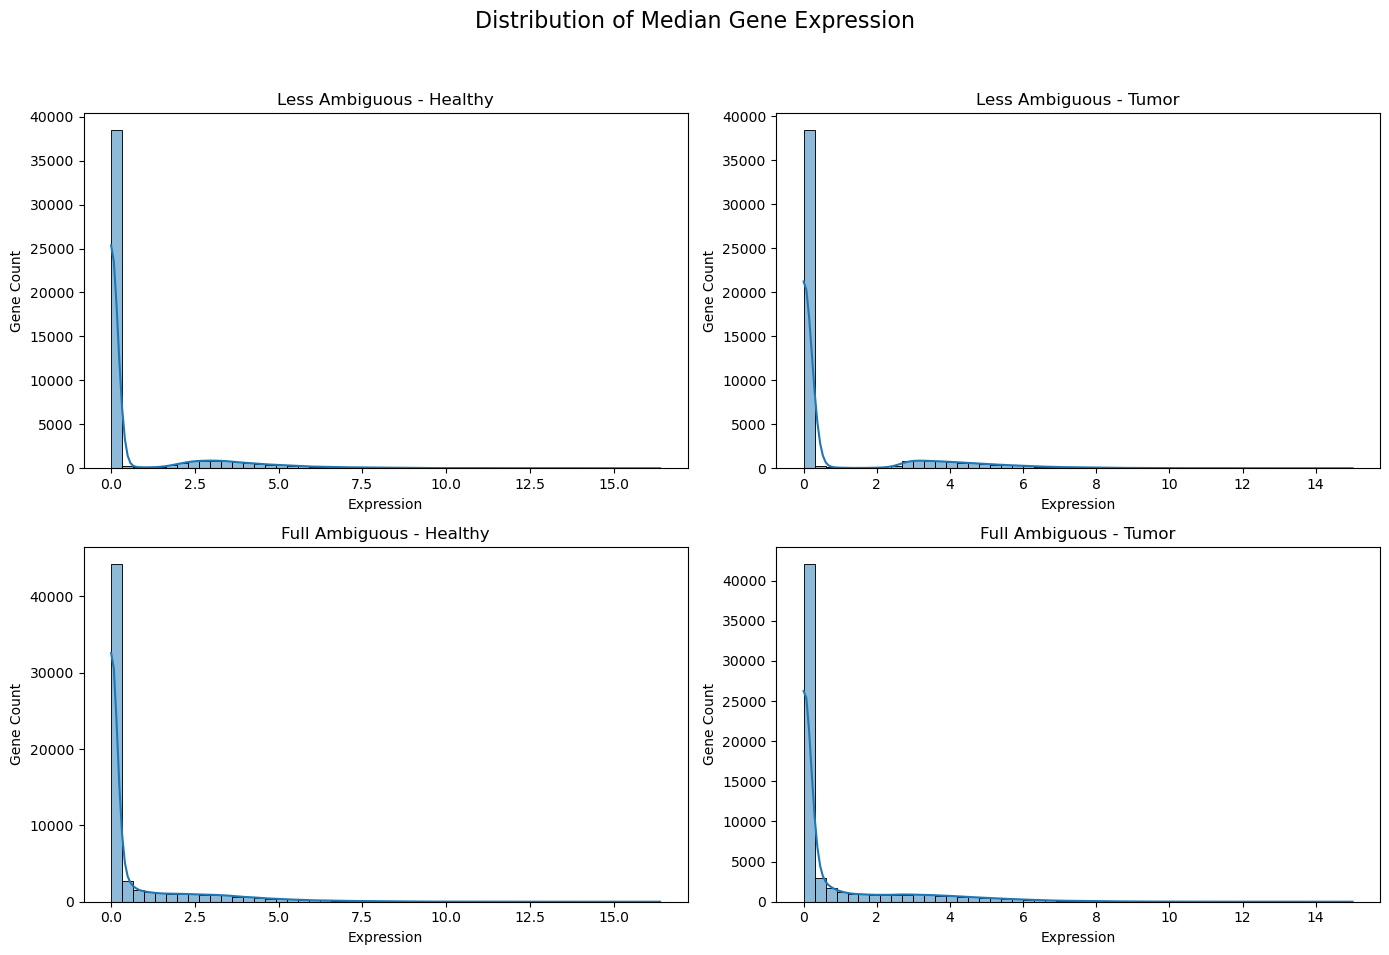

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribution of Median Gene Expression", fontsize=16)

# Top-left
sns.histplot(tcga_Ambfilt_cont_healthy_median, bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Less Ambiguous - Healthy")
axes[0, 0].set_xlabel("Expression")
axes[0, 0].set_ylabel("Gene Count")

# Top-right
sns.histplot(tcga_Ambfilt_cont_tumor_median, bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Less Ambiguous - Tumor")
axes[0, 1].set_xlabel("Expression")
axes[0, 1].set_ylabel("Gene Count")

# Bottom-left
sns.histplot(tcga_full_cont_healthy_median, bins=50, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Full Ambiguous - Healthy")
axes[1, 0].set_xlabel("Expression")
axes[1, 0].set_ylabel("Gene Count")

# Bottom-right
sns.histplot(tcga_full_cont_tumor_median, bins=50, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Full Ambiguous - Tumor")
axes[1, 1].set_xlabel("Expression")
axes[1, 1].set_ylabel("Gene Count")

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Exporting data 

In [76]:
# Reformating 
#For Full data 
tcga_full_continuous_tumor_median = tcga_full_cont_tumor_median .reset_index()
tcga_full_continuous_tumor_median.columns = ['GeneID', 'Expression']

tcga_full_continuous_healthy_median = tcga_full_cont_healthy_median.reset_index()
tcga_full_continuous_healthy_median.columns = ['GeneID', 'Expression']

#For less ambigous
tcga_less_continuous_tumor_median = tcga_Ambfilt_cont_tumor_median.reset_index()
tcga_less_continuous_tumor_median.columns = ['GeneID', 'Expression']

tcga_less_continuous_healthy_median = tcga_Ambfilt_cont_healthy_median.reset_index()
tcga_less_continuous_healthy_median.columns = ['GeneID', 'Expression']


In [77]:
# Exporting values 
# Full data
tcga_full_continuous_tumor_median.to_csv("tumor_full_cont_vector.txt", sep="\t", index=False, header=False)
tcga_full_continuous_healthy_median.to_csv("healthy__full_cont_vector.txt", sep="\t", index=False, header=False)

# Less ambigous
tcga_less_continuous_tumor_median.to_csv("tumor_Ambfilt_cont_vector.txt", sep="\t", index=False, header=False)
tcga_less_continuous_healthy_median.to_csv("healthy_Ambfilt_cont_vector.txt", sep="\t", index=False, header=False)

# Z score experiment

In [ ]:
# Calculate the median and range for each gene
gene_medians = tcga_only.median(axis=1)
gene_max = tcga_only.max(axis=1)
gene_min = tcga_only.min(axis=1)
gene_range = gene_max - gene_min

# Combine into a single DataFrame for inspection
range_df = pd.DataFrame({
    "median": gene_medians,
    "min": gene_min,
    "max": gene_max,
    "range": gene_range
})

# Sort to see genes with low median but high range
interesting_genes = range_df.sort_values(by=["median", "range"], ascending=[True, False])

# Show
print(interesting_genes.shape[0])
print(interesting_genes.head())

In [ ]:
# Estimate "off-state" gene expression across ALL samples
off_mean = tcga_only.mean(axis=1)
off_std  = tcga_only.std(axis=1)

# Convert mean and std Series to NumPy arrays before 
z_scores = (tcga_only - off_mean.to_numpy().reshape(-1, 1)) / off_std.to_numpy().reshape(-1, 1)

z_scores

In [ ]:
# Flatten all values (ignore NaNs)
z_flat = z_scores.values.flatten()
z_flat = z_flat[~np.isnan(z_flat)]  # Remove NaNs

# Plot the distribution
plt.figure(figsize=(8, 5))
sns.histplot(z_flat, bins=100, kde=True)
#plt.yscale('log')
plt.title("Distribution of Z-Scores (All Genes × All Tumor Samples)")
plt.xlabel("Z-score")
plt.ylabel("Frequency")
plt.axvline(0, color='black', linestyle='--', label='(z=0)')
plt.axvline(0.03, color='green', linestyle='--', label='z = +1')
plt.axvline(-0.03, color='red', linestyle='--', label='z = -1')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Spliting Z-score matrix into tumor and healthy samples
z_tumor   = z_scores.loc[:, z_scores.columns.str.contains("Tumor")]
z_healthy = z_scores.loc[:, z_scores.columns.str.contains("Healthy")]

In [ ]:
# Distribution after spliting 
# Flatten Z-scores, remove NaNs
z_tumor_flat = z_tumor.values.flatten()
z_tumor_flat = z_tumor_flat[~np.isnan(z_tumor_flat)]

z_healthy_flat = z_healthy.values.flatten()
z_healthy_flat = z_healthy_flat[~np.isnan(z_healthy_flat)]

# Plot side-by-side
plt.figure(figsize=(14, 5))

# Tumor
plt.subplot(1, 2, 1)
sns.histplot(z_tumor_flat, bins=100, kde=True)
plt.title("Z-Score Distribution: Tumor Samples")
plt.xlabel("Z-score")
plt.ylabel("Frequency")
plt.axvline(0, color='black', linestyle='--', label='z = 0')
plt.axvline(1, color='green', linestyle='--', label='z = +1')
plt.axvline(-1, color='red', linestyle='--', label='z = -1')
plt.legend()

# Healthy
plt.subplot(1, 2, 2)
sns.histplot(z_healthy_flat, bins=100, kde=True)
plt.title("Z-Score Distribution: Healthy Samples")
plt.xlabel("Z-score")
plt.ylabel("Frequency")
plt.axvline(0, color='black', linestyle='--', label='z = 0')
plt.axvline(1, color='green', linestyle='--', label='z = +1')
plt.axvline(-1, color='red', linestyle='--', label='z = -1')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Collapsing into +1,-1 and 0 
# Collapsing fucntion 
def collapse_to_imat_vector(z_df, thresh= 0.5, ratio=0.25):
    expressed = (z_df >  thresh).sum(axis=1)
    unexpressed = (z_df < -thresh).sum(axis=1)
    total = (~z_df.isna()).sum(axis=1)
    
    imat_vector = np.zeros(z_df.shape[0])
    imat_vector[expressed / total >= ratio] = 1
    imat_vector[unexpressed / total >= ratio] = -1
    return imat_vector

In [ ]:
# Collapse
imat_vector_tumor   = collapse_to_imat_vector(z_tumor)
imat_vector_healthy = collapse_to_imat_vector(z_healthy)

In [ ]:
import matplotlib.pyplot as plt

# Count values
tumor_counts = pd.Series(imat_vector_tumor).value_counts().sort_index()
healthy_counts = pd.Series(imat_vector_healthy).value_counts().sort_index()

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Tumor
axes[0].bar(tumor_counts.index.astype(str), tumor_counts.values, color='tomato')
axes[0].set_title("Tumor iMAT Vector")
axes[0].set_xlabel("Expression category")
axes[0].set_ylabel("Gene count")

# Healthy
axes[1].bar(healthy_counts.index.astype(str), healthy_counts.values, color='teal')
axes[1].set_title("Healthy iMAT Vector")
axes[1].set_xlabel("Expression category")

plt.tight_layout()
plt.show()

In [ ]:
# Reformat for MATLAB
imat_vector_tumor = pd.DataFrame({
    'GeneID': z_tumor.index,
    'Expression': imat_vector_tumor
}).reset_index(drop=True)

imat_vector_healthy = pd.DataFrame({
    'GeneID': z_healthy.index,
    'Expression': imat_vector_healthy
}).reset_index(drop=True)

In [ ]:
# Exporting for MATLAB
output_path = "/Users/valentinreateguirangel/dissertation_project/Z score model"

# Export tumor
pd.DataFrame(imat_vector_tumor).to_csv(
    output_path + "imat_vector_tumor.txt", sep="\t", index=False, header=False)

# Export healthy
pd.DataFrame(imat_vector_healthy).to_csv(
    output_path + "imat_vector_healthy.txt", sep="\t", index=False, header=False)

In [ ]:
pd.DataFrame(imat_vector_tumor).value_counts()